# Premières étapes
## Import des packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from category_encoders.target_encoder import TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from alibi.explainers import ALE, plot_ale
import lime
import lime.lime_tabular
from IPython.display import display, HTML
import shap

c:\Users\isali\Documents\cours\M2_ECAP\SVM_projet\projet_svm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import des données

In [2]:
df = pd.read_csv('data/raw/StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# Vérification des doublons
print(df.duplicated().sum())

# Infos sur les données
df.info()

0
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity

Pas de doublons.
6607 observations, 18 variables explicatives pour 1 variable cible : Exam_Score.
Les types des variables semblent bien correspondre aux données.
On constate la présence de valeurs manquantes dans Teacher_Quality, Parental_Education_Level, et Distance_From_Home.

## Train test split
### Séparation

In [4]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Vérification de l'équilibre de la variable cible après le split

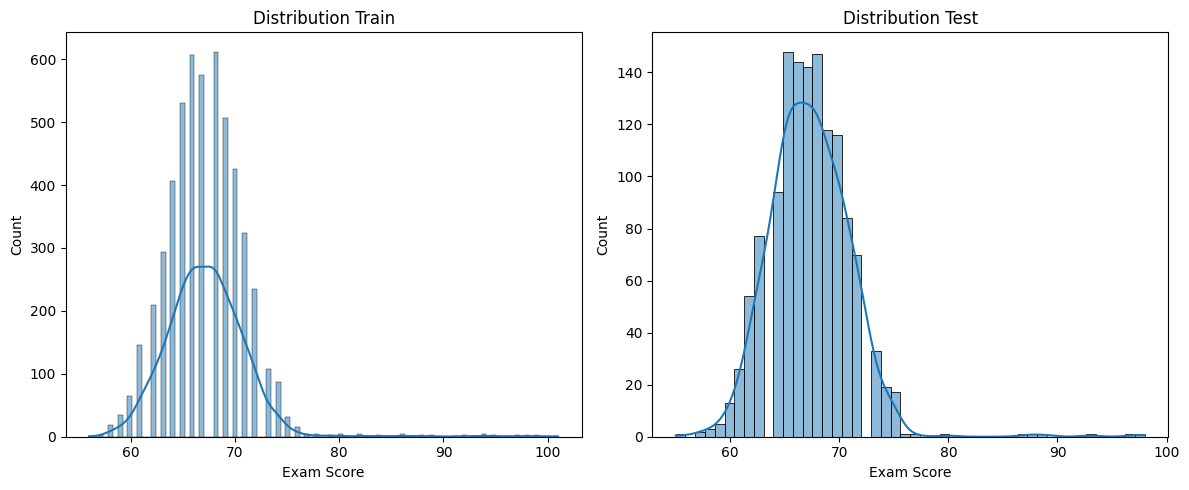

In [5]:
# Vérification sur variables numériques
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Train
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title("Distribution Train")
axes[0].set_xlabel("Exam Score")

# Test
sns.histplot(y_test, kde=True, ax=axes[1])
axes[1].set_title("Distribution Test")
axes[1].set_xlabel("Exam Score")

plt.tight_layout()
plt.show()

La distribution de la variable cible semble bien équilibrée entre le jeu train et le jeu test. Le jeu test est ainsi une bonne représentation du jeu train pour la régression.

## Création d'un df train, test et concatené 

In [6]:
# Copie des datasets
df_train = X_train.copy()
df_test = X_test.copy()

# Ajout de la target 
df_train["Exam_Score"] = y_train
df_test["Exam_Score"] = y_test

# Ajout de la source
df_train["__source__"] = "train"
df_test["__source__"] = "test"

# Fusion
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

# Vérification
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

# Nettoyage et visualisation des données
## Création de listes de variables en fonction du type

In [7]:
# Colonnes quantitatives (numériques)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Colonnes qualitatives catégorielles (texte)
cat_cols = df.select_dtypes(include=['str']).columns.tolist()

## Création d'une palette de couleurs

In [8]:
palette = sns.color_palette("pastel", 10)

## Analyse descriptives univariées
### Variables numériques

In [9]:
# Statistiques descriptives
df.describe() 

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Les moyennes sont proches des médianes, ce qui indique des distributions plutôt normales.

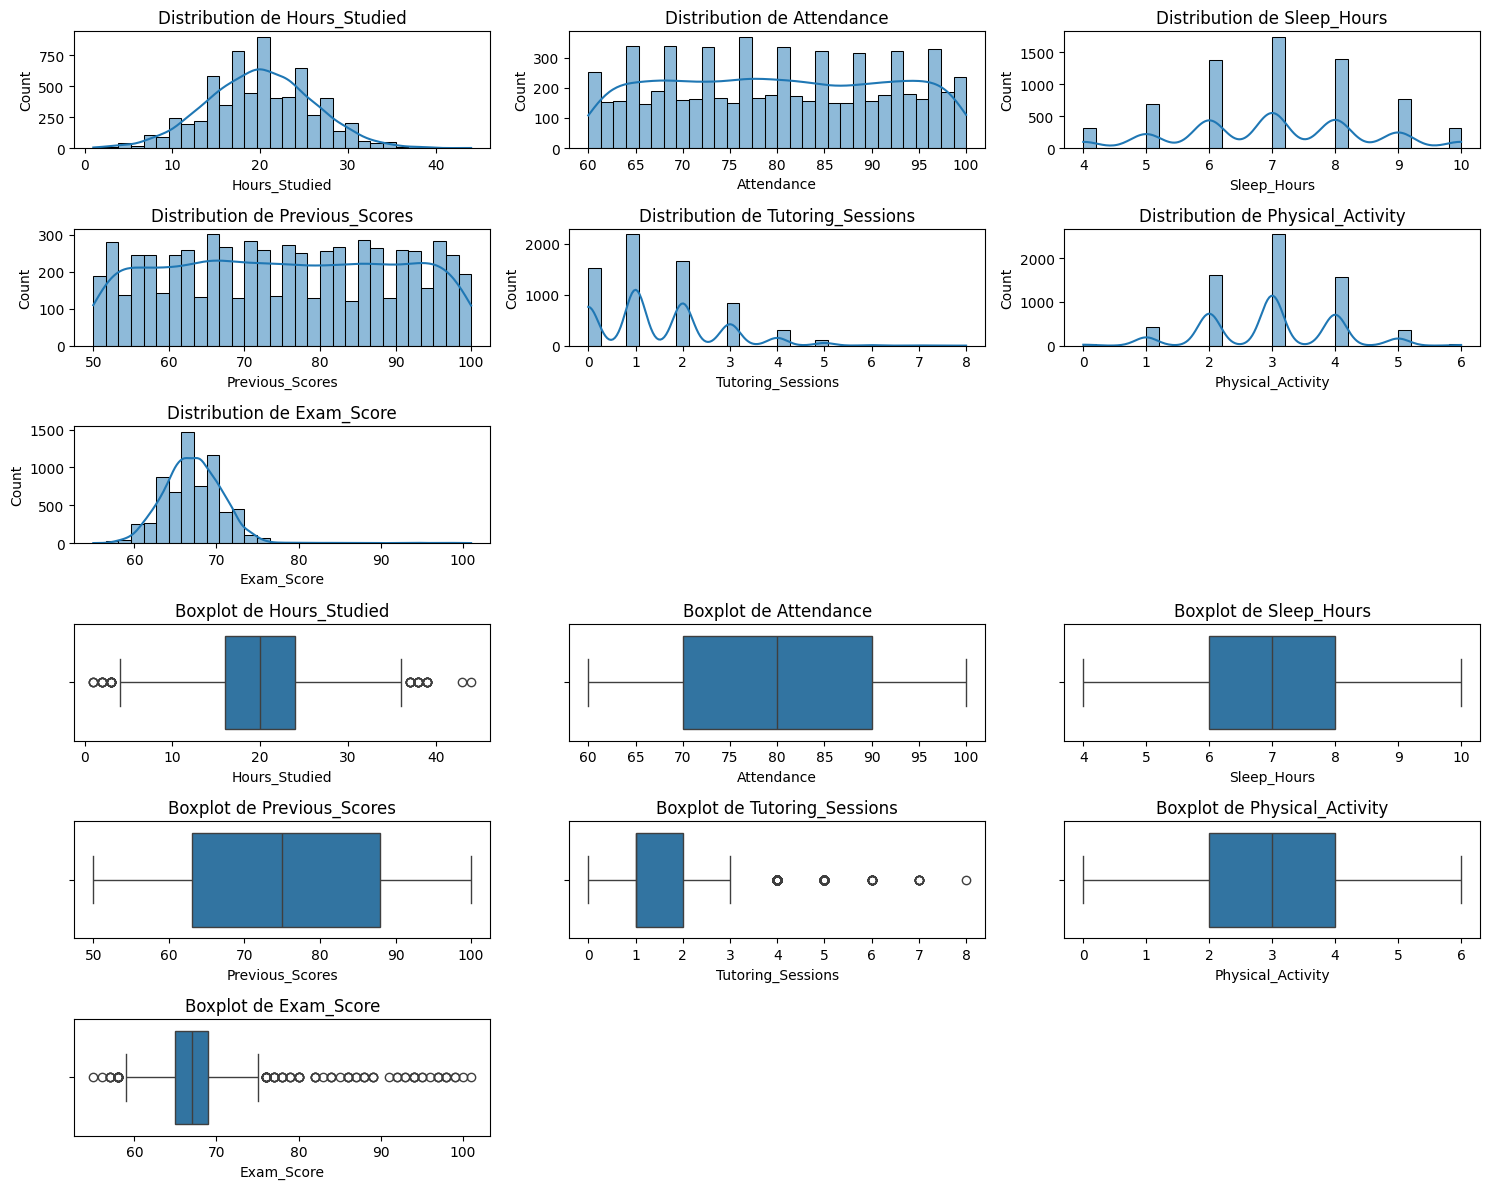

In [10]:
# Histogrammes et Boxplots 

num_cols = df.select_dtypes(include=[np.number]).columns
n_vars = len(num_cols)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(
    2 * n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, col in enumerate(num_cols):
    # Indices de ligne / colonne
    row = i // n_cols
    col_idx = i % n_cols

    # Histogramme
    ax_hist = axes[row, col_idx]
    sns.histplot(df[col], bins=30, kde=True, ax=ax_hist)
    ax_hist.set_title(f"Distribution de {col}")

    # Boxplot
    ax_box = axes[row + n_rows, col_idx]
    sns.boxplot(x=df[col], ax=ax_box)
    ax_box.set_title(f"Boxplot de {col}")

# Masque les axes vides
for j in range(n_vars, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes[r, c].axis("off")
    axes[r + n_rows, c].axis("off")

plt.tight_layout()
plt.show()

Les distributions des variables quantitatives semblent suivre la Loi Normale, à l'exception de *Attendance*, *Previous_Score* et *Efficiency*.
On observe la présence de potentielles valeurs extrêmes dans *Hours_Studied*, *Tutoring_Sessions*, *Exam_Score* et *Efficiency*.

#### Traitement des valeurs extrêmes
Nous ne traiterons pas les valeurs extrêmes de la variable à prédire *Exam_Score*, afin de ne pas modifier sa distribution.

In [11]:
target_col = "Exam_Score"

# Colonnes numériques sans la target
num_cols_no_targ = df_train.select_dtypes(include=["int64", "float64"]).columns
num_cols_no_targ = [col for col in num_cols_no_targ if col != target_col]
quantiles = {}

# calcul uniquement sur les variables numériques
for col in num_cols_no_targ:
    low = df_train[col].quantile(0.01)
    high = df_train[col].quantile(0.99)
    quantiles[col] = (low, high)
    n_changed = ((df_train[col] < quantiles[col][0]) | 
                 (df_train[col] > quantiles[col][1])).sum()
    
    print(f"{col}: {n_changed} valeurs modifiées")

def apply_winsorization(df, quantiles):
    df = df.copy()
    for col, (low, high) in quantiles.items():
        df[col] = df[col].clip(low, high)
    return df

# Application de la winsorization sur les jeux d'entraînement et de test
df_train_no_out = apply_winsorization(df_train, quantiles)
df_test_no_out = apply_winsorization(df_test, quantiles)

# Reconstruction du df complet après nettoyage des valeurs extrêmes
df_no_out = pd.concat([df_train_no_out, df_test_no_out], axis=0, ignore_index=True)

Hours_Studied: 87 valeurs modifiées
Attendance: 0 valeurs modifiées
Sleep_Hours: 0 valeurs modifiées
Previous_Scores: 52 valeurs modifiées
Tutoring_Sessions: 24 valeurs modifiées
Physical_Activity: 59 valeurs modifiées


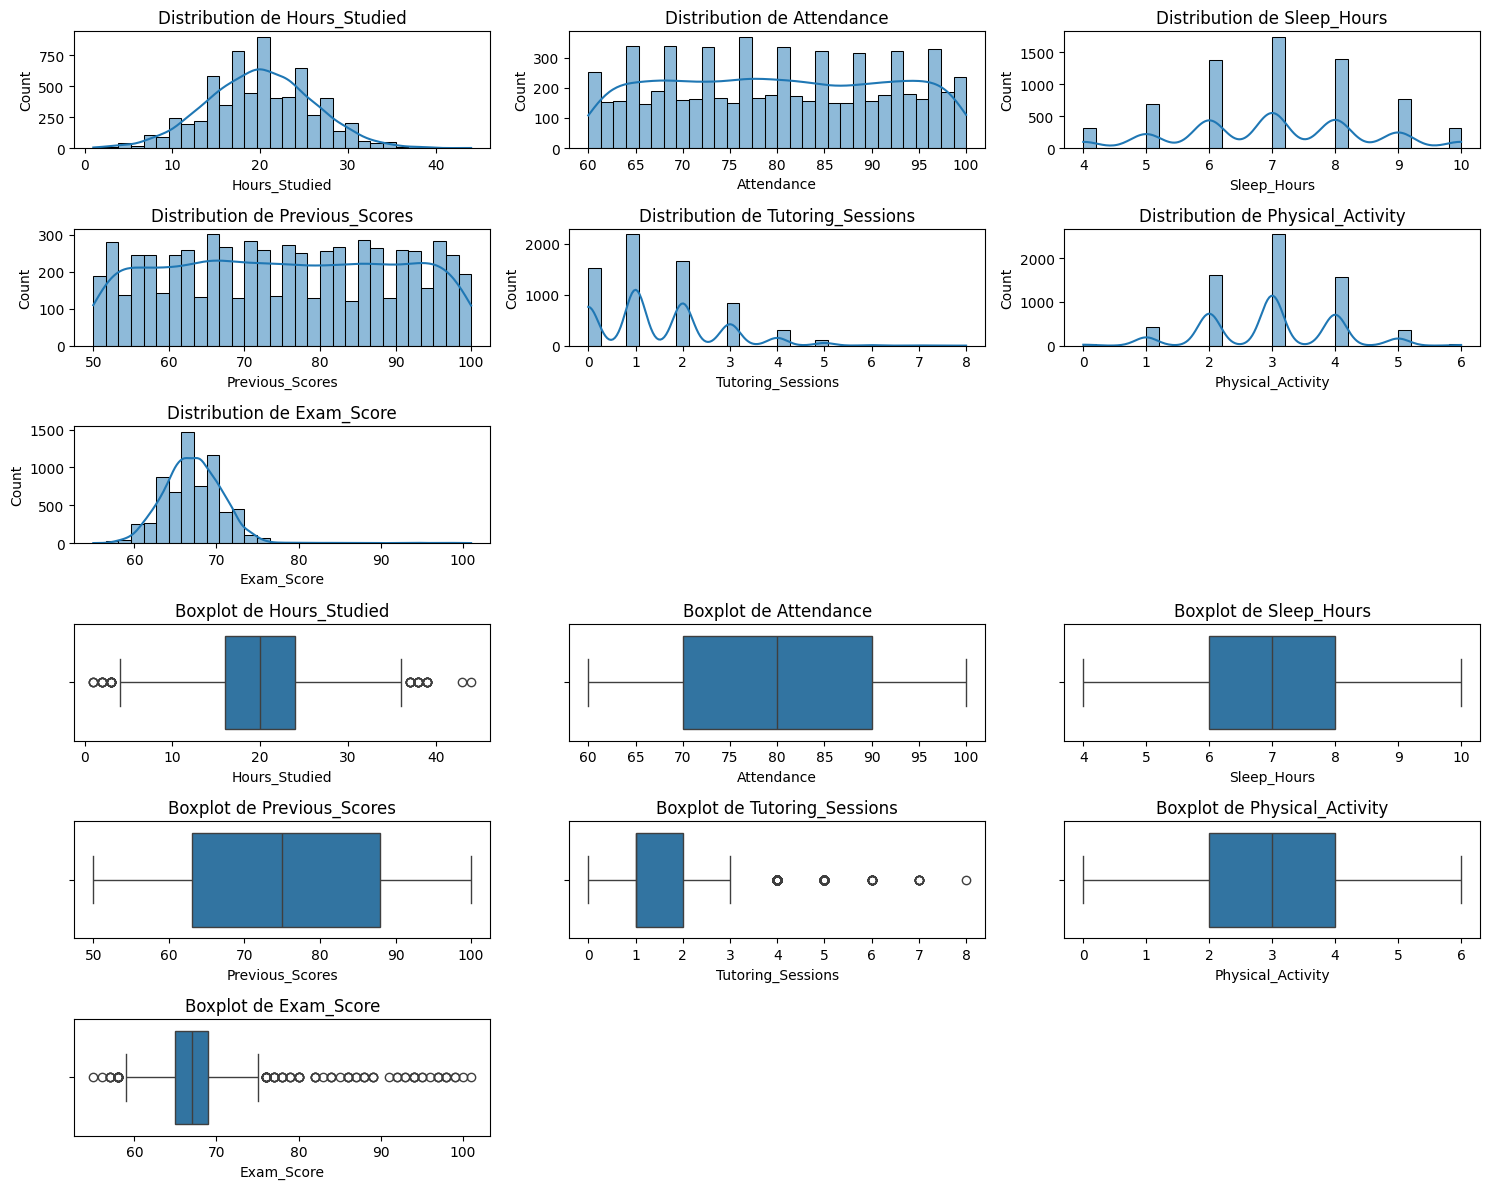

In [12]:
# Histogrammes et Boxplots après traitements des outliers

n_vars = len(num_cols)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(
    2 * n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, col in enumerate(num_cols):
    # Indices de ligne / colonne
    row = i // n_cols
    col_idx = i % n_cols

    # Histogramme
    ax_hist = axes[row, col_idx]
    sns.histplot(df[col], bins=30, kde=True, ax=ax_hist)
    ax_hist.set_title(f"Distribution de {col}")

    # Boxplot
    ax_box = axes[row + n_rows, col_idx]
    sns.boxplot(x=df[col], ax=ax_box)
    ax_box.set_title(f"Boxplot de {col}")

# Masque les axes vides
for j in range(n_vars, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes[r, c].axis("off")
    axes[r + n_rows, c].axis("off")

plt.tight_layout()
plt.show()

Les distributions semblent davantage suivre la Loi Normale et la majorité des potentielles valeurs atypiques ont disparu, sauf pour *Tutoring_Sessions* pour laquelle nous constatons qu'il y a toujours quelques valeurs s'écartant de la médiane.

### Variables catégorielles

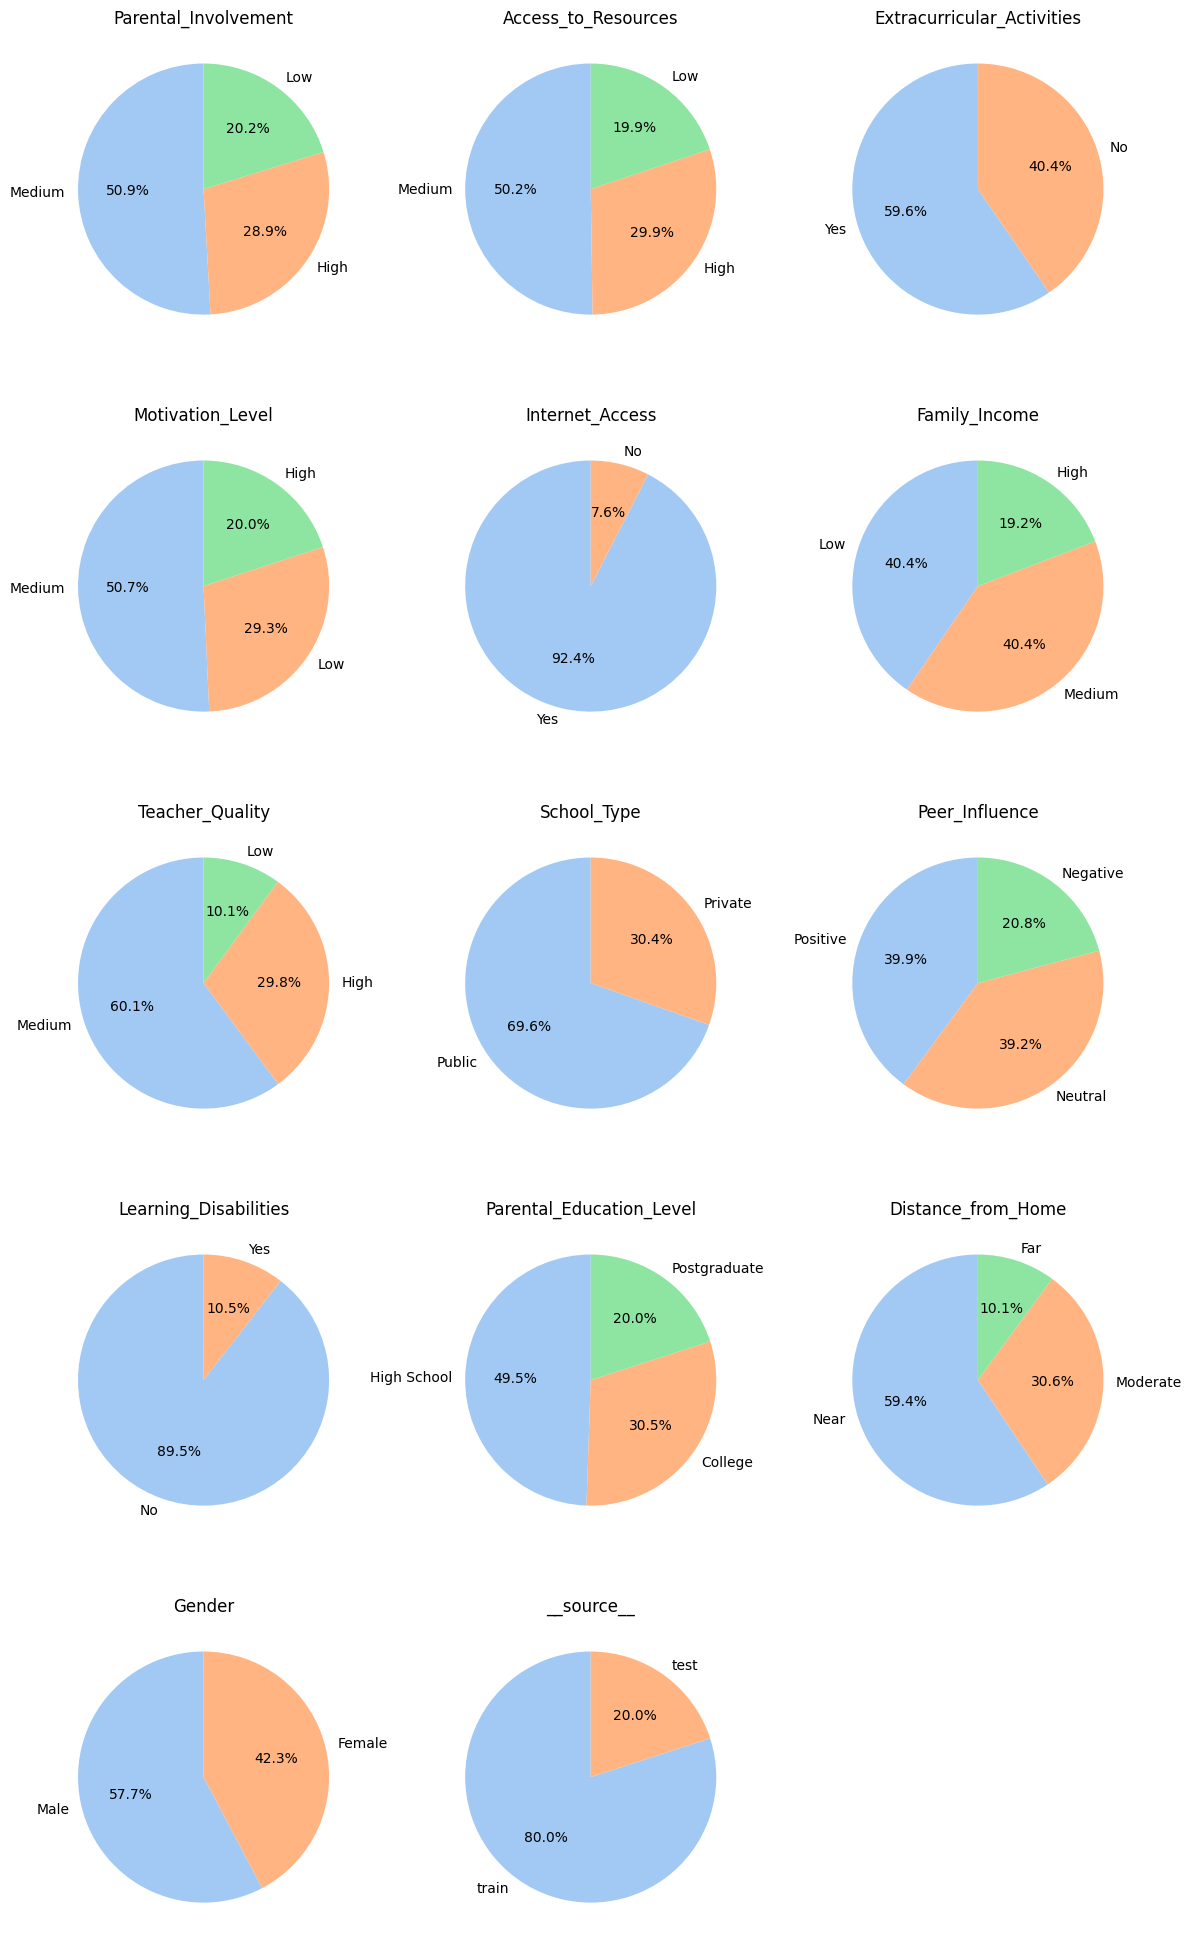

In [13]:
# Pie Chart pour variables catégorielles
def plot_pie(data, columns):

    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
    axes = axes.flatten()

    for i, col in enumerate(columns):

        counts = data[col].value_counts()

        axes[i].pie(
            counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=palette
        )

        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Affichage 
plot_pie(df_no_out, cat_cols)

La plupart des variables catégorielles ne montrent pas la présence de modalités avec un très faible pourcentage de valeurs. Il n'est alors pas nécessaire de regrouper ces catégories entre elles.

### Corrélations entre variables explicatives numériques

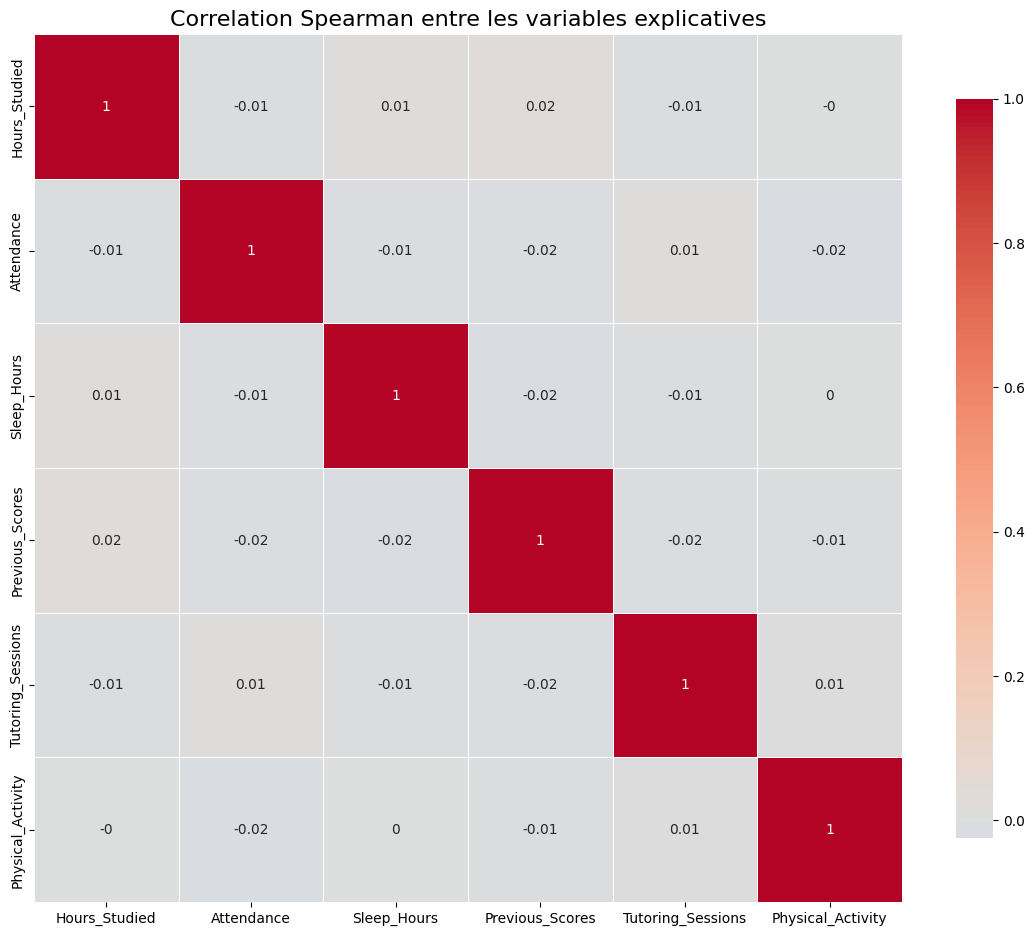

In [14]:
# Correlation map avec spearman entre les variables explicatives
# Exclusion de la variable cible
x_cols = [c for c in num_cols if c != "Exam_Score"]

# Application de la méthode de corrélation de Spearman
corr = df_no_out[x_cols].corr(method='spearman')

# Figure
plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=corr.round(2), cmap="coolwarm", center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Correlation Spearman entre les variables explicatives", fontsize=16)
plt.show()

Le jeu de données étant fictif, nous retrouvons uniquement des corrélations quasiment inexistantes pour les variables de base. Cela ne pose pas de problème pour la réalisation de modèles de regréssions mais cela limite néanmoins le réalisme de ce dataset et donc des résultats que nous obtiendrons.

### Corrélation entre variables qualitatives

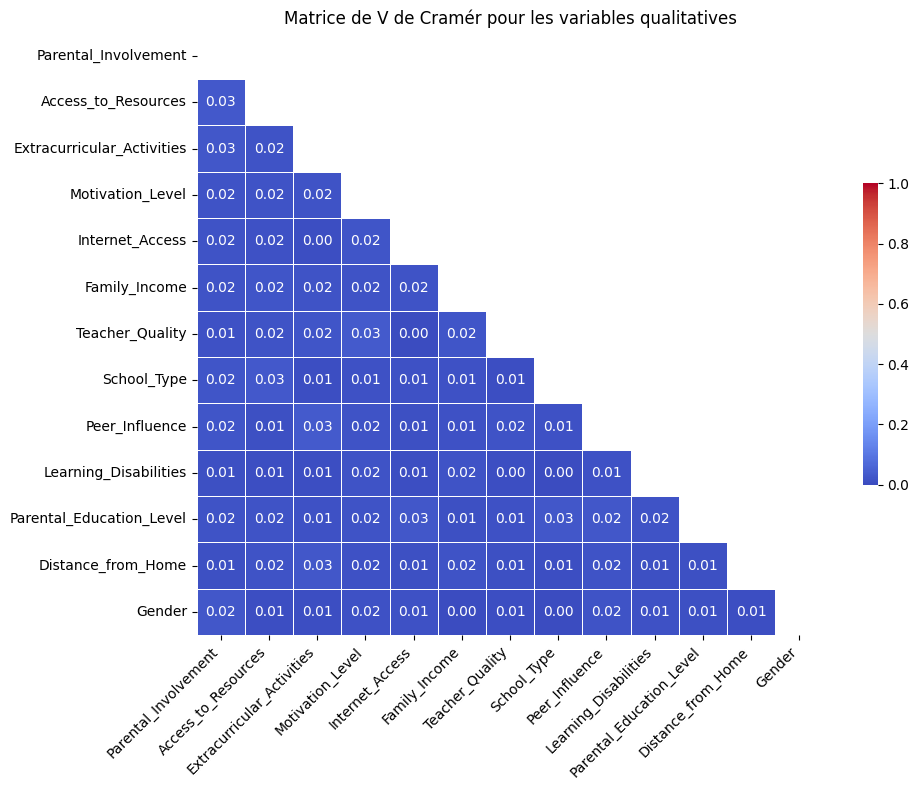

In [15]:
# Matrice de V de Cramer sous forme de heatmap

# Liste des variables catégorielles à analyser, en excluant la source
col_source = "__source__"
cat_cols_no_source = [col for col in df.select_dtypes(include=['str']).columns.tolist() if col != col_source]

# Création de la matrice de V de Cramer
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

cramer_matrix = pd.DataFrame(
    np.zeros((len(cat_cols_no_source), len(cat_cols_no_source))),
    index=cat_cols_no_source,
    columns=cat_cols_no_source
)

for col1 in cat_cols_no_source:
    for col2 in cat_cols_no_source:
        cramer_matrix.loc[col1, col2] = cramers_v(df_no_out[col1], df_no_out[col2])

## Figure et Heatmap
### Masque pour le triangle supérieur
mask = np.triu(np.ones_like(cramer_matrix, dtype=bool))

### Affichage
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramer_matrix.astype(float),
    mask=mask,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    center=0.5,
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={"shrink": 0.5},
    annot_kws={"size": 10}
)

plt.title("Matrice de V de Cramér pour les variables qualitatives")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

De la même façon que pour les variables numériques, il n'existe que des corrélations extremement faibles entre les variables qualitatives. 

Dans le cas inverse, nous aurions pu sélectionner les variables à inclure dans notre modèle de telle sorte à ce qu'il n'existe pas de variables fortement corrélées entre elles. Cela pourrait notamment se faire en supprimant une à une les variables les plus corrélées à d'autres, puis en recalculant les corrélations après chaque suppression, jusqu'à ce qu'il n'existe plus de corrélations fortes selon un seuil définit, supérieures à 0,8 ou 0,7 par exemple. 

### Analyse des relations entre variables quantitatives et la variables cible

C:\Users\isali\AppData\Local\Temp\ipykernel_1304\1149723631.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)
C:\Users\isali\AppData\Local\Temp\ipykernel_1304\1149723631.py:5: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)


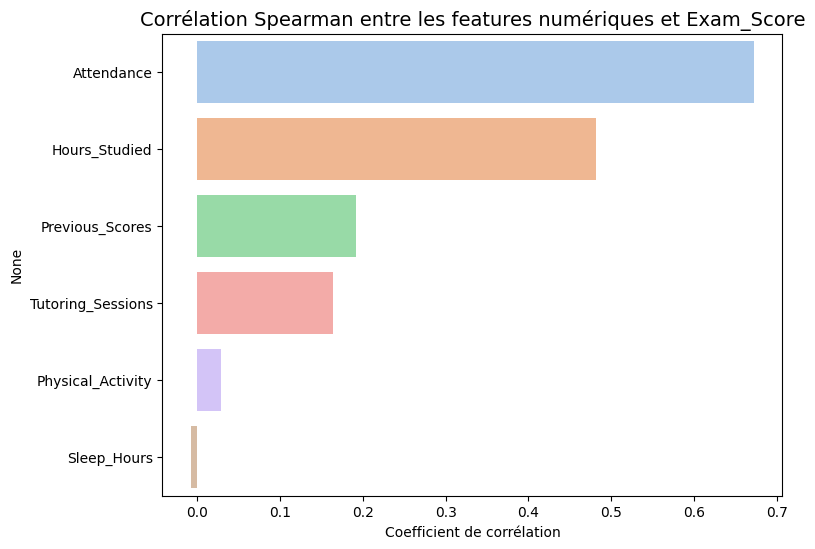

In [16]:
# Corrélation entre les variables explicatives numériques et la variable cible
corr_target = df_no_out[x_cols + ["Exam_Score"]].corr(method="spearman")["Exam_Score"].drop("Exam_Score").sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)
plt.title("Corrélation Spearman entre les features numériques et Exam_Score", fontsize=14)
plt.xlabel("Coefficient de corrélation")
plt.show()

## Analyse descriptive multivariée
### Analyse des relations entre variables qualitatives et la variable cible

C:\Users\isali\AppData\Local\Temp\ipykernel_1304\1195619092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_1304\1195619092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_1304\1195619092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_1304\1195619092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

<Figure size 1400x3000 with 0 Axes>

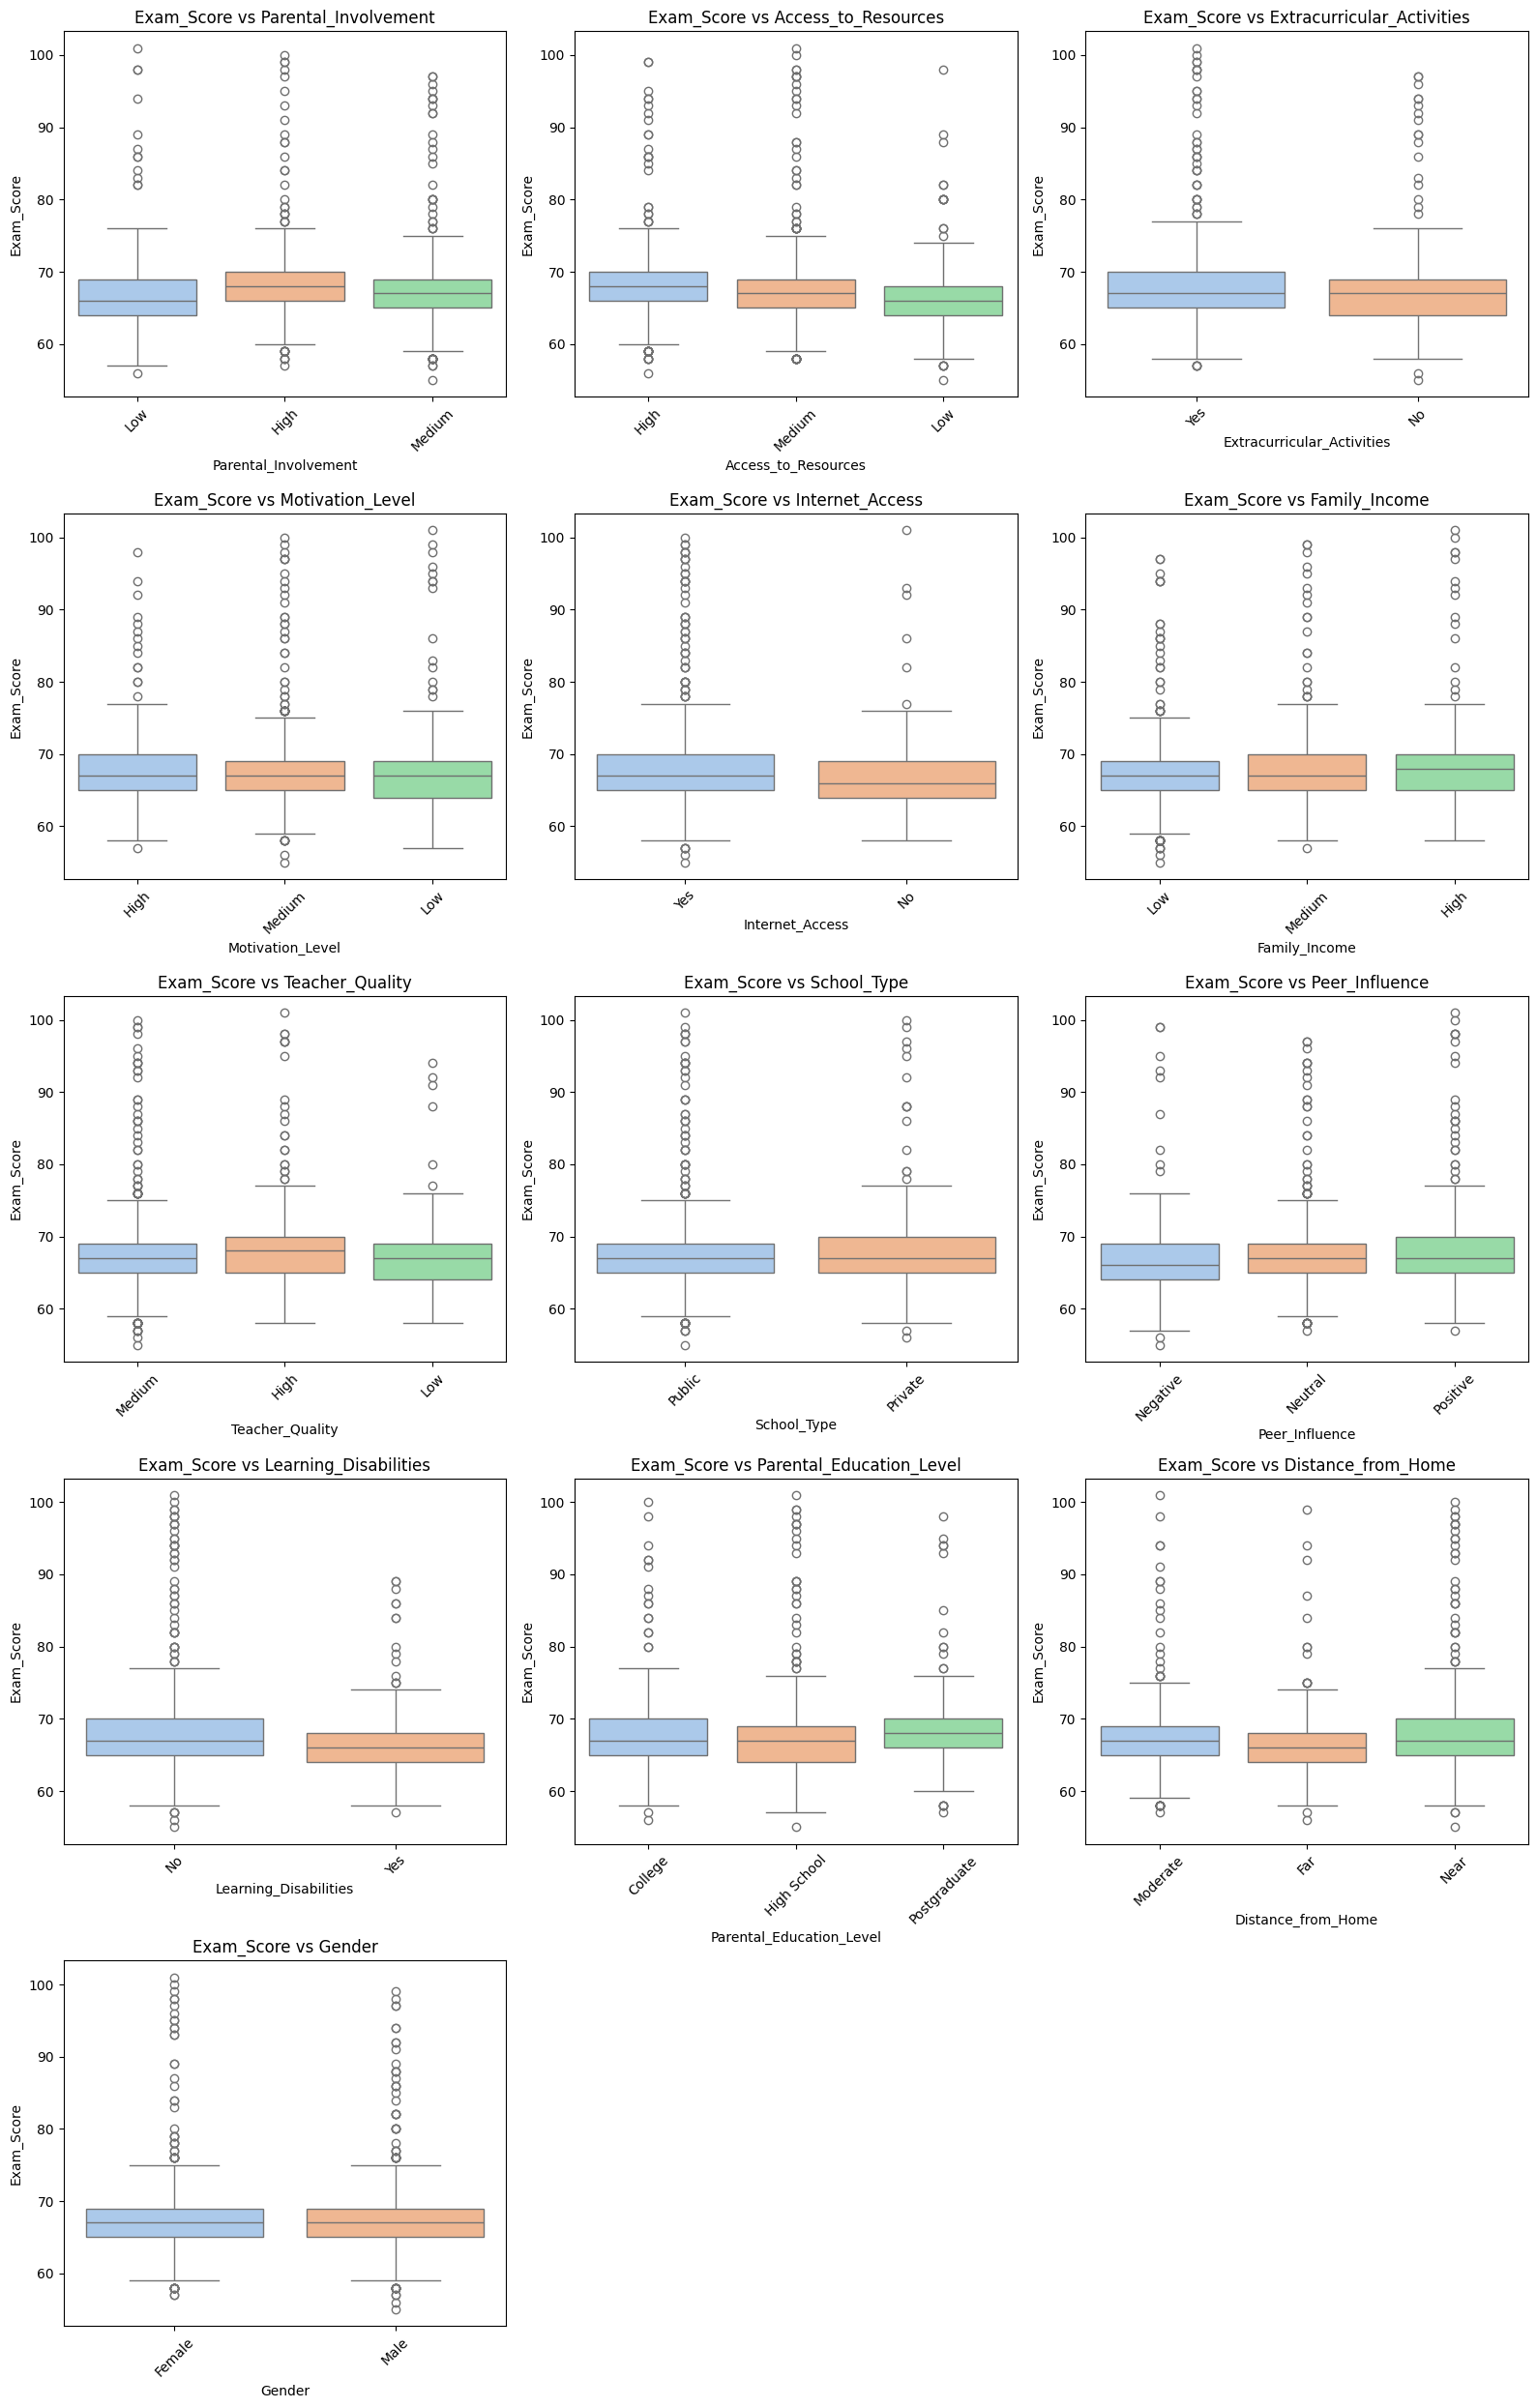

In [17]:
plt.figure(figsize=(14, 30))

# Nombre de variables qualitatives
n_cols = 3
n_rows = (len(cat_cols_no_source) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
axes = axes.flatten()

for i, cat in enumerate(cat_cols_no_source):
    sns.boxplot(
        data=df_no_out,
        x=cat,
        y="Exam_Score",
        ax=axes[i],
        palette="pastel"
    )
    axes[i].set_title(f"Exam_Score vs {cat}")
    axes[i].tick_params(axis="x", rotation=45)

# Supprimer les axes vides si le nombre de sous-plots dépasse le nombre de variables
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Traitements avant modélisation
## Traitement des valeurs manquantes 
Tout ce qui dépend de statistiques (taux de NA, colonnes à drop, catégories à ajouter) doit être calculé uniquement sur le train, afin d'éviter le data leakage.
Les règles appliquées sur le train seront ensuite appliquées sur le test.

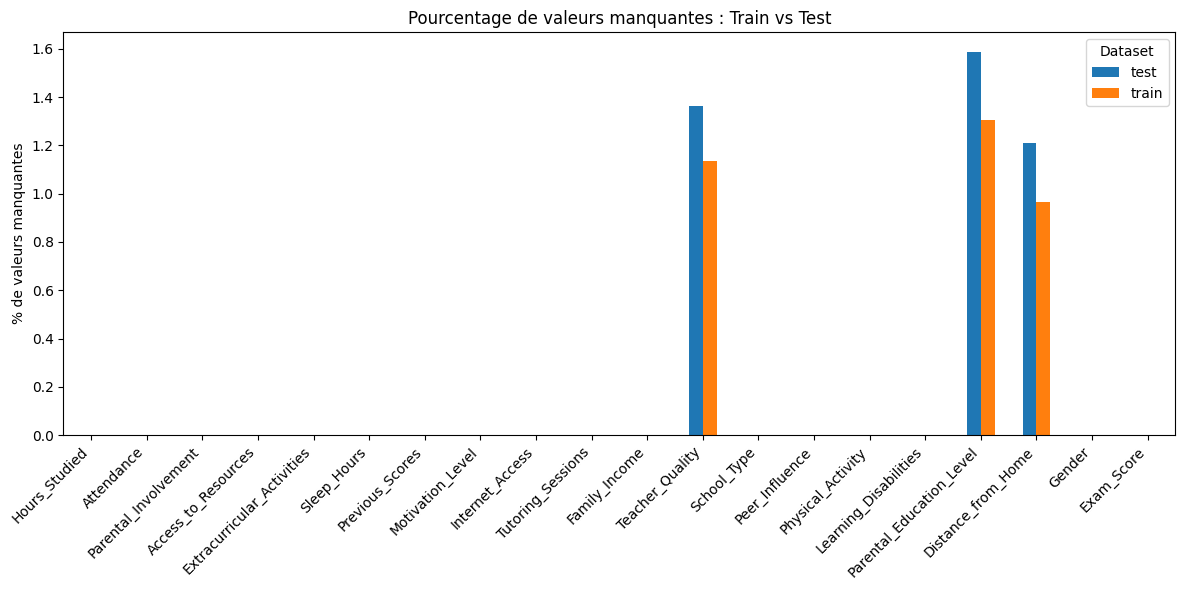

In [18]:
# Calcul du % de valeurs manquantes par colonne et par source
missing_pct = (
    df_no_out.groupby("__source__")
      .apply(lambda x: x.isna().mean() * 100)
      .T  # transpose pour avoir les variables en index
)

# Figure
missing_pct.plot(kind="bar", figsize=(12,6))

plt.title("Pourcentage de valeurs manquantes : Train vs Test")
plt.ylabel("% de valeurs manquantes")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

Le pourcentage de valeurs manquantes par variable étant très faibles pour chacune des colonnes concernées, nous pouvons remplacer ces valeurs.
Etant donné que l'analyse descriptive n'a pas permis d'étblir des corrélations importantes entre les différentes variables, cela complique l'imputation des valeurs manquantes par ...
Nous pouvons alors les remplacer par la modalité la plus fréquente.

In [19]:
# Colonnes avec valeurs manquantes
missing_cols = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

# Initialisation de l'imputation avec la modalité la plus fréquente
cat_imputer = SimpleImputer(strategy="most_frequent")

# FIT uniquement sur le train
cat_imputer.fit(df_train_no_out[missing_cols])

# TRANSFORM sur train et test
df_train_no_na = df_train_no_out.copy()
df_test_no_na = df_test_no_out.copy()
df_train_no_na[missing_cols] = cat_imputer.transform(df_train_no_out[missing_cols])
df_test_no_na[missing_cols] = cat_imputer.transform(df_test_no_out[missing_cols])

# Reconstruction du df complet après nettoyage des valeurs manquantes
df_no_na = pd.concat([df_train_no_na, df_test_no_na], axis=0, ignore_index=True)

# Vérification des valeurs manquantes après imputation
print(df_no_na.isna().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
__source__                    0
dtype: int64


# Feature Engineering
## Création de variables
Afin d'améliorer l'éfficacité de notre modèle, nous testerons l'ajout de nouvelles variables crées à partir de nos variables actuelles ou avec intéractions.

In [20]:
# Contexte parentale
df_fe = df_no_na.copy()
df_fe["Parent_Context"] = (
    df_fe["Parental_Education_Level"].astype(str) + "_" +
    df_fe["Family_Income"].astype(str)
)

# Efficacité du travail
df_fe["Efficiency"] = df_fe["Previous_Scores"] / (df_fe["Hours_Studied"] + 1)

# Vérification
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Family_Income               6607 non-null   str    
 11  Teacher_Quality             6607 non-null   str    
 12  School_Type                 6607 non-null   str    
 13  Peer_Influence              6607 non-null   

Ces ajouts ne sont pas fait à partir des statistiques globales, et peuvent donc être fait directement sur le df complet.
Nous devons néanmoins re découper le df en train et test à partir de la colonne source, afin d'appliquer ces modifications sur les df train et test.

In [21]:
# Split train/test depuis le df complet 
df_train_fe = df_fe[df_fe["__source__"] == "train"].copy()
df_test_fe = df_fe[df_fe["__source__"] == "test"].copy()

# Vérification 
print(df_fe.info())
print(df_train_fe.info())
print(df_test_fe.info())

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Family_Income               6607 non-null   str    
 11  Teacher_Quality             6607 non-null   str    
 12  School_Type                 6607 non-null   str    
 13  Peer_Influence              6607 non-null   

count    6607.000000
mean        3.945380
std         1.665762
min         1.457143
25%         2.842928
50%         3.562500
75%         4.571429
max        14.142857
Name: Efficiency, dtype: float64


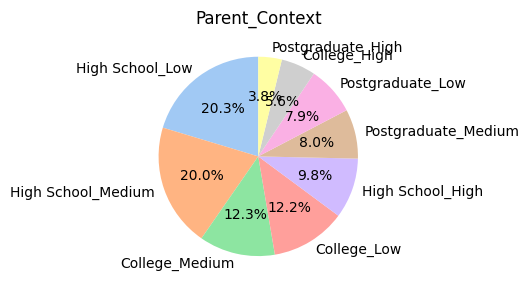

In [22]:
# Analyse descriptive des nouvelles features
print(df_fe["Efficiency"].describe())

plot_pie(df_fe, ["Parent_Context"])

*Parent_Context* contient 2 modalités avec peu d'observations (<6%). Afin d'améliorer la pertinence de la variable pour notre modèle, nous pouvons regrouper ces 2 catégories en une seule catégorie "Autres".

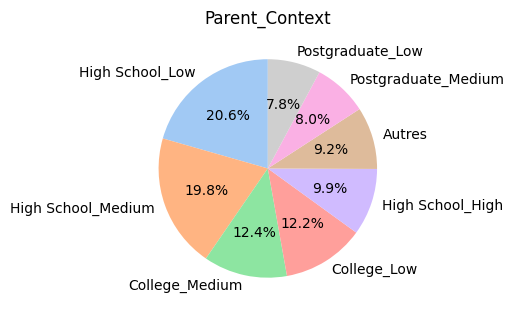

In [23]:
### Regroupement Parent_Context
# Colonne à traiter
col = "Parent_Context"
threshold = 0.06

# Conversion de col en variable catégorielle dans df_train 
df_train_fe[col] = df_train_fe[col].astype("category")

# Calcul des catégories rares (uniquement sur train)
freq = df_train_fe[col].value_counts(normalize=True)
rare_categories = freq[freq < threshold].index

# Ajout de "Autres"
df_train_fe[col] = df_train_fe[col].cat.add_categories("Autres")

# Remplacement des rares
df_train_fe[col] = df_train_fe[col].replace(rare_categories, "Autres")

# Suppression des anciennes catégories rares
df_train_fe[col] = df_train_fe[col].cat.remove_unused_categories()

# Plot après regroupement
plot_pie(df_train_fe, ["Parent_Context"])

In [24]:
# Application du même traitement sur le test
df_test_fe[col] = df_test_fe[col].astype("category")
df_test_fe[col] = df_test_fe[col].cat.add_categories("Autres")
df_test_fe[col] = df_test_fe[col].replace(rare_categories, "Autres")
df_test_fe[col] = df_test_fe[col].cat.remove_unused_categories()

# Concaténation du df complet après regroupement des catégories rares
df_fe = pd.concat([df_train_fe, df_test_fe], axis=0, ignore_index=True)
df_fe["Parent_Context"].value_counts(normalize=True)

Parent_Context
High School_Low        0.203421
High School_Medium     0.200091
College_Medium         0.123203
College_Low            0.121840
High School_High       0.097926
Autres                 0.094143
Postgraduate_Medium    0.080218
Postgraduate_Low       0.079158
Name: proportion, dtype: float64

In [25]:
# Reconstruction des X_train et X_test après imputation et transformations
X_train = df_train_fe.drop(columns=["__source__"])
X_test = df_test_fe.drop(columns=["__source__"])

## Encodage des variables catégorielles
L'encodage doit être fait sur train pour éviter le data leakage.
Plusieurs méthodes sont possibles, notamment les suivantes : 
- One-Hot Encoding, pour les variables avec peu de modalités (<3)
- Target Encoding, pour les variables avec beaucoup de modalités (>3)
- Ordinal Encoder, lorsqu'on veut conserver l'odre naturel des catégories
- ...
### Définition des règles

In [26]:
# Variable cible
TARGET = "Exam_Score"

# On remet "Parent_Context" en format str
df_train_fe[col] = df_train_fe[col].astype('str')

# Colonnes catégorielles
cat_cols = [col for col in df_train_fe.select_dtypes(include="object").columns 
            if col not in ["__source__", "Exam_Score"]] 

# Séparation selon le nombre de modalités
cat_ohe = [c for c in cat_cols if df_train_fe[c].nunique() <= 3]
cat_target = [c for c in cat_cols if df_train_fe[c].nunique() > 3]

print("Variables en One-Hot Encoding :", cat_ohe)
print("Variables en Target Encoding :", cat_target)

Variables en One-Hot Encoding : ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Variables en Target Encoding : ['Parent_Context']


C:\Users\isali\AppData\Local\Temp\ipykernel_1304\1755839059.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [col for col in df_train_fe.select_dtypes(include="object").columns


In [27]:
# One-Hot encoding
ohe = OneHotEncoder(
    sparse_output=False,
    drop=None,
    handle_unknown="ignore"
)

X_ohe = pd.DataFrame(
    ohe.fit_transform(df_train_fe[cat_ohe]),
    columns=ohe.get_feature_names_out(cat_ohe),
    index=df_train_fe.index
)

In [28]:
# Target encoding
te = TargetEncoder(
    cols=cat_target,
    smoothing=10  # régularisation (important pour éviter l'overfitting)
)

X_te = te.fit_transform(
    df_train_fe[cat_target],
    df_train_fe[TARGET]
)

In [29]:
# Variables numériques (hors cible)
num_cols = df_train_fe.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]
X_num = df_train_fe[num_cols]

# Dataset final prêt pour la modélisation
X = pd.concat(
    [X_num, X_ohe, X_te],
    axis=1
)
y = df_train_fe[TARGET]

# Vérification
print("Shape X :", X.shape)
print("Shape y :", y.shape)

encoded_train = pd.concat(
    [X, y],
    axis=1
)
print(encoded_train.head())

Shape X : (5285, 42)
Shape y : (5285,)
   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0             27          79            8               63                  2   
1             16          86            7               94                  2   
2             22          87            8               83                  1   
3             18         100           10               86                  1   
4             34          78           10               99                  1   

   Physical_Activity  Efficiency  Parental_Involvement_High  \
0                  5    2.250000                        0.0   
1                  3    5.529412                        1.0   
2                  1    3.608696                        0.0   
3                  3    4.526316                        1.0   
4                  2    2.828571                        1.0   

   Parental_Involvement_Low  Parental_Involvement_Medium  ...  \
0                       1.0   

In [30]:
# Encodage test (réutilisation de celui du train, pour éviter la fuite d'information)
# Encodage One-Hot pour les variables avec 3 modalités ou moins
X_ohe_test = pd.DataFrame(
    ohe.transform(df_test_fe[cat_ohe]),  # on utilise ohe déjà fit sur le train
    columns=ohe.get_feature_names_out(cat_ohe),
    index=df_test_fe.index
)

# Encodage Target pour les variables avec > 3 modalités
X_te_test = te.transform(df_test_fe[cat_target])  # on utilise te déjà fit sur le train

# Variables numériques
num_cols_test = df_test_fe.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()
# On exclut la cible si elle est présente dans le test
num_cols_test = [c for c in num_cols_test if c != TARGET]
X_num_test = df_test_fe[num_cols_test]

# Assemblage du dataset test
X_test = pd.concat([X_num_test, X_ohe_test, X_te_test], axis=1)

# Vérification
print("Shape X_test :", X_test.shape)
print(X_test.head())

y_test = df_test_fe[TARGET]
encoded_test = pd.concat([X_test, y_test], axis=1)

Shape X_test : (1322, 42)
      Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
5285             20          71            7               87   
5286             22          71            7               98   
5287             21          91            6               53   
5288             12          91            8               81   
5289             21          63            8               95   

      Tutoring_Sessions  Physical_Activity  Efficiency  \
5285                  1                  5    4.142857   
5286                  2                  2    4.260870   
5287                  1                  3    2.409091   
5288                  0                  4    6.230769   
5289                  2                  5    4.318182   

      Parental_Involvement_High  Parental_Involvement_Low  \
5285                        0.0                       0.0   
5286                        0.0                       0.0   
5287                        1.0                    

In [31]:
# Définition de X et y
X_train = encoded_train.drop('Exam_Score', axis=1)
y_train = encoded_train['Exam_Score']
X_test = encoded_test.drop('Exam_Score', axis=1)
y_test = encoded_test['Exam_Score']

# Concaténation des jeux de données train et test
X = pd.concat([X_train, X_test], axis=0)
y = pd.concat([y_train, y_test], axis=0)

# Vérification
print("Shape X train :", X_train.shape)
print("Shape y train :", y_train.shape)
print("Shape X test :", X_test.shape)
print("Shape y test :", y_test.shape)
print("Shape X :", X.shape)

Shape X train : (5285, 42)
Shape y train : (5285,)
Shape X test : (1322, 42)
Shape y test : (1322,)
Shape X : (6607, 42)


## Normalisation des features
Les variables n'ayant pas la même échelle de mesure, il est important de les normaliser afin de rendre les coefficients comparables dans le cadre de certains modèles de Machine Learning.

In [35]:
# Identification des variables numériques et target encodés à scaler
cols_to_scale = [
    "Hours_Studied", "Attendance", "Sleep_Hours", 
    "Previous_Scores", "Tutoring_Sessions", 
    "Physical_Activity", "Efficiency", "Parent_Context"
]

scaler = StandardScaler()

# Copies
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

# Fit sur train uniquement
X_train_sc[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform sur test
X_test_sc[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Vérification de la shape
print(X_train_sc.shape, X_test_sc.shape, y_train.shape, y_test.shape)
print(X_train_sc.head())

(5285, 42) (1322, 42) (5285,) (1322,)
   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0       1.193757   -0.075846     0.669094        -0.838937           0.418309   
1      -0.673466    0.531894    -0.016740         1.315578           0.418309   
2       0.345019    0.618714     0.669094         0.551073          -0.407218   
3      -0.333971    1.747376     2.040764         0.759574          -0.407218   
4       2.381990   -0.162667     2.040764         1.663081          -0.407218   

   Physical_Activity  Efficiency  Parental_Involvement_High  \
0           2.016522   -1.012561                        0.0   
1           0.029514    0.939383                        1.0   
2          -1.957495   -0.203850                        0.0   
3           0.029514    0.342328                        1.0   
4          -0.963990   -0.668188                        1.0   

   Parental_Involvement_Low  Parental_Involvement_Medium  ...  \
0                       1.0    

# Modélisation
## Fonction d'évaluation des modèles

In [36]:
def evaluate_model(model, X_test, y_test):
    # Fonction pour évaluer les modèles de régression

    # Prédiction des valeurs de la variable cible pour les données de test
    y_pred = model.predict(X_test)
    # Retourne le R2
    print(f"Évaluation du modèle : {model.__class__.__name__}")
    r2 = r2_score(y_test, y_pred)
    print(f"R²   : {r2:.4f}")
    # Retourne les métriques MSE et MAE
    print(f"Performance sur le jeu de test :")
    # Calcul du MSE
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE  : {mse:.4f}")
    # Calcul du MAE
    mae = mean_absolute_error(y_test, y_pred)
    print(f"MAE  : {mae:.4f}")
    return None

## Modèles 
### Régression Linéaire

In [ ]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred = lr.predict(X_test_sc)

evaluate_model(lr, X_test_sc, y_test)

In [ ]:
# Coefficients
coef_df = pd.DataFrame({
    "feature": X_train_sc.columns,
    "coefficient": lr.coef_
})

print(coef_df.sort_values(by="coefficient", ascending=False))

### Arbres de décisions

In [ ]:
tree = DecisionTreeRegressor(random_state=42)
# Définition de la grille de recherche des hyperparamètres
tree_param_grid = {
    "criterion": ["squared_error", "absolute_error"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}

# Grid Search avec validation croisée
grid_search_tree = GridSearchCV(estimator=tree, param_grid=tree_param_grid, cv=5, n_jobs=-1, scoring='r2', verbose=2)
grid_search_tree.fit(X_train_sc, y_train)
print(grid_search_tree.best_params_)

In [ ]:
# Modèle optimisé
tree = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    max_features=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_test_sc)

# Evaluation du modèle
evaluate_model(tree, X_test_sc, y_test)

In [ ]:
# Visualisation de l'arbre
plt.figure(figsize=(30, 15))  # figure plus large
plot_tree(
    tree,
    filled=True,
    feature_names=X_train_sc.columns,
    fontsize=14,              
    rounded=True             
)
plt.show()

### Random Forest

In [ ]:
rf = RandomForestRegressor(random_state=42)
# Définition de la grille de recherche des hyperparamètres
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search avec validation croisée, par rapport au r2
grid_search_rf = GridSearchCV(estimator=rf, param_grid=rf_param_grid, cv=5, n_jobs=-1, scoring='r2', verbose=2)
grid_search_rf.fit(X_train_sc, y_train)
print(grid_search_rf.best_params_)

In [ ]:
# Création du modèle
rf = RandomForestRegressor(n_estimators=100,
                            max_depth=5,
                            min_samples_split=10,
                            min_samples_leaf=2,
                            random_state=42)

# Entrainement du modèle
rf.fit(X_train, y_train)

# Prédiction des valeurs de la variable cible pour les données de test
y_pred = rf.predict(X_test_sc)

# Evaluation du modèle
evaluate_model(rf, X_test_sc, y_test)

### Adaboost

In [ ]:
adaboost = AdaBoostRegressor(random_state=42)
adaboost_param_grid = {
    'n_estimators': [100, 150, 200, 250, 300, 350, 400],
    'estimator': [DecisionTreeRegressor(max_depth=d) for d in [2, 3, 4, 5, 6]],
    'loss': ['linear', 'square', 'exponential'],
    'learning_rate': [0.05, 0.1, 0.15],
}

grid_search_adaboost = GridSearchCV(estimator=adaboost, param_grid=adaboost_param_grid, cv=5, n_jobs=-1, scoring='r2', verbose=2)
grid_search_adaboost.fit(X_train_sc, y_train)
print(grid_search_adaboost.best_params_)

In [ ]:
# Création du modèle
adb = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                            n_estimators=200,
                            loss='linear',
                            learning_rate=0.15,
                            random_state=42)

# Entrainement du modèle
adb.fit(X_train, y_train)

# Evaluation du modèle
evaluate_model(adb, X_test_sc, y_test)

### XGBoost

In [ ]:
xgboost = XGBRegressor(random_state=42)
# Définition de la grille de recherche des hyperparamètres
xgboost_param_grid = {
    'n_estimators': [150, 200, 250, 300, 350, 400],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.05, 0.07, 0.1, 0.12, 0.15, 0.2],
    'sub_sample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Grid Search avec validation croisée
grid_search_xgb = GridSearchCV(estimator=xgboost, param_grid=xgboost_param_grid, cv=5, n_jobs=-1, scoring='r2', verbose=2)
grid_search_xgb.fit(X_train_sc, y_train)
print(grid_search_xgb.best_params_)

In [ ]:
# Visualisation de la performance du modèle selon le grid search
# Transformation des résultats du GridSearch en DataFrame
results_df = pd.DataFrame(grid_search_xgb.cv_results_)

# Sélection des colonnes importantes pour la visualisation
plot_df = results_df[['param_n_estimators', 'param_max_depth', 'param_learning_rate', 
                      'param_sub_sample', 'param_colsample_bytree', 'mean_test_score']].copy()

# Conversion des hyperparamètres en float pour plotting si nécessaire
for col in ['param_n_estimators', 'param_max_depth', 'param_learning_rate', 
            'param_sub_sample', 'param_colsample_bytree']:
    plot_df[col] = plot_df[col].astype(float)

# Scatter plot: n_estimators vs mean_test_score, hue=max_depth, size=learning_rate
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(
    data=plot_df,
    x='param_n_estimators',
    y='mean_test_score',
    hue='param_max_depth',         
    size='param_learning_rate',   
    palette='Blues',
    sizes=(50, 200),
    alpha=0.8
)

# Annotation du meilleur score
best = grid_search_xgb.best_index_
best_row = results_df.iloc[best]
plt.scatter(
    best_row['param_n_estimators'],
    best_row['mean_test_score'],
    color='red', s=250, edgecolor='black', label='Meilleur score'
)
plt.text(best_row['param_n_estimators'], 
         best_row['mean_test_score']+0.005,
         f"Best: {best_row['mean_test_score']:.3f}", 
         color='red', fontweight='bold')

plt.title("GridSearch XGBoost : n_estimators vs mean_test_score")
plt.xlabel("Nombre d'estimators")
plt.ylabel("R2 moyen (CV)")
plt.legend(title="Max Depth / Learning Rate", bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [ ]:
xgb = XGBRegressor(n_estimators=300,
                    random_state=42,
                    learning_rate=0.05,
                    subsample=0.6,
                    colsample_bytree=0.6,
                    max_depth=5)

# Entrainement du modèle
xgb.fit(X_train, y_train)

# Evaluation du modèle
evaluate_model(xgb, X_test, y_test)

### SVM

## Conclusion sur le meilleur modèle

# Interprétation du meilleur modèle